In [1]:
import numpy as np
import pandas as pd
from astropy.table import Table
import matplotlib.pyplot as plt
import pyvinecopulib as pv

In [2]:
from utils import load_photo_z_cats, add_photom, load_waves_photom

In [3]:
photo_cat = load_photo_z_cats()
waves_photom = load_waves_photom()
photo_cat = add_photom(photo_cat, waves_photom)

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

In [104]:
# ugriZYJHK photom
photo_cat['zeta'] = np.log(photo_cat['Z'] +1)
data = photo_cat[['Z', 'mag_ut', 'mag_gt', 'mag_rt', 'mag_it', 'mag_Zt', 'mag_Yt', 'mag_Jt', 'mag_Ht', 'mag_Kt']]


In [105]:
# generarte colums u-g, g-r, r-i, i-Z, Z-Y, Y-J, J-H, H-K
#data['u-g'] = data['mag_ut'] - data['mag_gt']
#data['g-r'] = data['mag_gt'] - data['mag_rt']
#data['r-i'] = data['mag_rt'] - data['mag_it']
#data['i-Z'] = data['mag_it'] - data['mag_Zt']
#data['Z-Y'] = data['mag_Zt'] - data['mag_Yt']
#data['Y-J'] = data['mag_Yt'] - data['mag_Jt']
#data['J-H'] = data['mag_Jt'] - data['mag_Ht']
#data['H-K'] = data['mag_Ht'] - data['mag_Kt']


In [ ]:
# generate colums that are likely to have useful information for photo-z estimation
data['u-r'] = data['mag_ut'] - data['mag_rt']
data['u-i'] = data['mag_ut'] - data['mag_it']
data['g-i'] = data['mag_gt'] - data['mag_it']
data['g-Z'] = data['mag_gt'] - data['mag_Zt']
data['g-i'] = data['mag_gt'] - data['mag_it']
data['r-Z'] = data['mag_rt'] - data['mag_Zt']
data['r-Y'] = data['mag_rt'] - data['mag_Yt']
data['r-J'] = data['mag_rt'] - data['mag_Jt']
data['i-J'] = data['mag_it'] - data['mag_Jt']
data['Z-J'] = data['mag_Zt'] - data['mag_Jt']

In [107]:
# drop rows with missing values
data = data.dropna()


In [108]:
data = data.to_numpy()
#del photo_cat, waves_photom

In [117]:
u = pv.to_pseudo_obs(data)

In [118]:

# randomly downsample u to 10000 rows
u = u[np.random.choice(u.shape[0], 100000, replace=True)]

In [119]:
u

array([[0.72273286, 0.79610536, 0.73522566, ..., 0.8001697 , 0.83656706,
        0.93739791],
       [0.32859191, 0.41022753, 0.54697427, ..., 0.66863373, 0.67337395,
        0.73592153],
       [0.26716534, 0.20719045, 0.19076594, ..., 0.57509943, 0.57836253,
        0.88836422],
       ...,
       [0.33848295, 0.56069346, 0.48806589, ..., 0.59910755, 0.6243784 ,
        0.93323546],
       [0.56793551, 0.71949883, 0.63824476, ..., 0.69532174, 0.74594157,
        0.70313792],
       [0.29166583, 0.4195081 , 0.45130697, ..., 0.3420858 , 0.38340689,
        0.36149906]], shape=(100000, 19))

KeyboardInterrupt: 

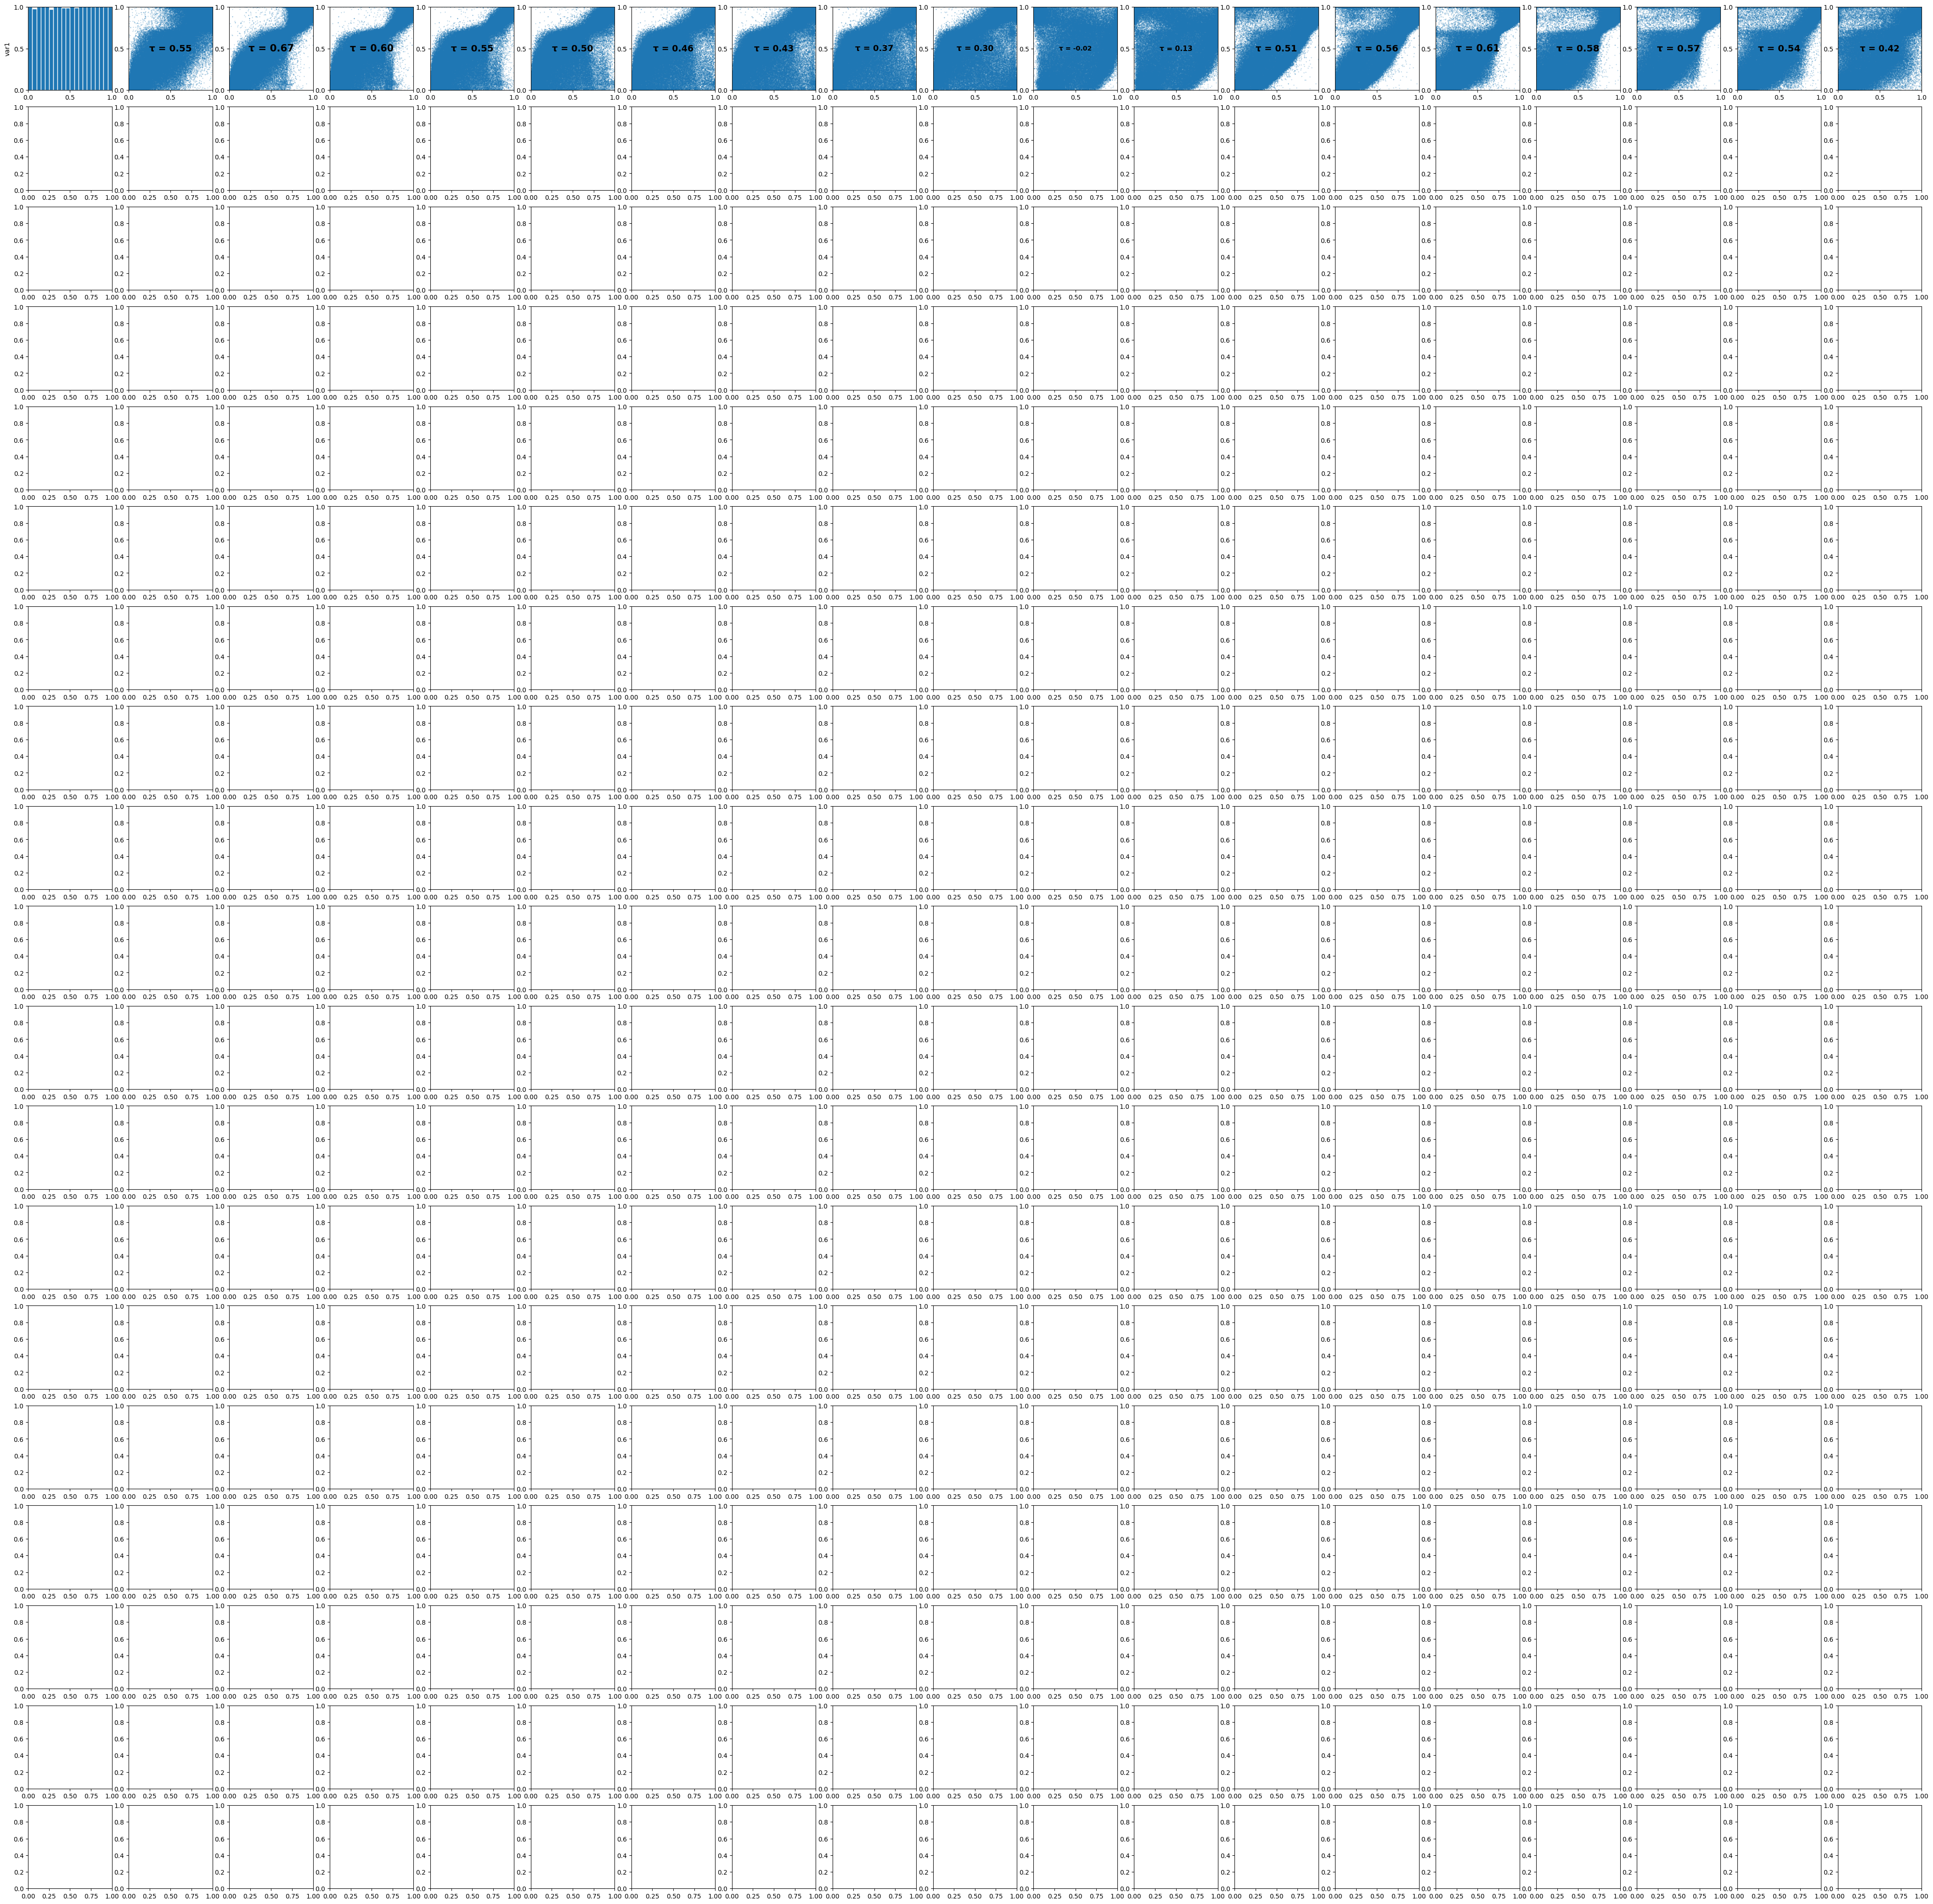

In [ ]:
#var_names = ["u", "g", "r", "i", "Z", "Y", "J", "H", "K", "z_spec"]
v = u[np.random.choice(u.shape[0], 5000, replace=True)]
pv.pairs_copula_data(u, scatter_size=0.1)

In [ ]:
controls = pv.FitControlsVinecop(
    family_set=[
#        pv.BicopFamily.gaussian,
#        pv.BicopFamily.student,
#        pv.BicopFamily.clayton,
#        pv.BicopFamily.gumbel,
#        pv.BicopFamily.frank,
#        pv.BicopFamily.joe,
#        pv.BicopFamily.bb1,
#        pv.BicopFamily.bb6,
#        pv.BicopFamily.bb7,
#        pv.BicopFamily.bb8,
#        pv.BicopFamily.tawn,
        pv.BicopFamily.tll
    ],
    tree_criterion="tau",          # Kendall's tau for MST edge weights
    selection_criterion="bic",
    select_trunc_lvl=False,         # auto-prune higher trees
    threshold=0.05,                 # start with no threshold
    select_threshold=False,        # set True to auto-select threshold
    num_threads=4,
)

cop = pv.Vinecop.from_data(u, controls=controls)
print(cop)

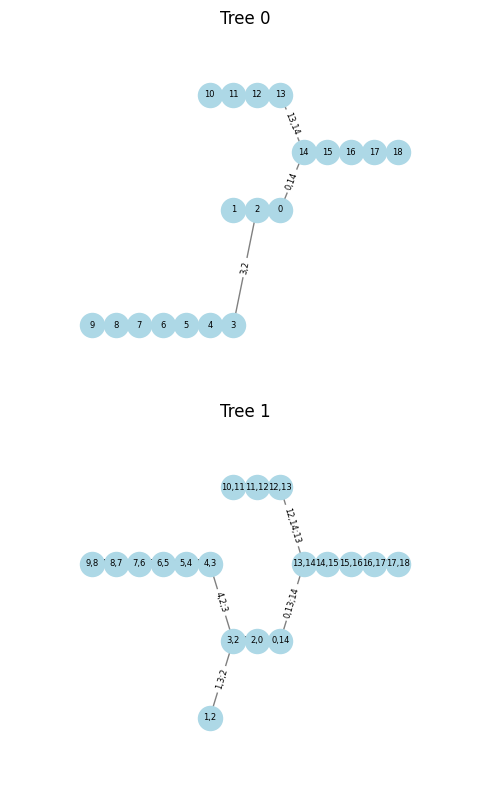

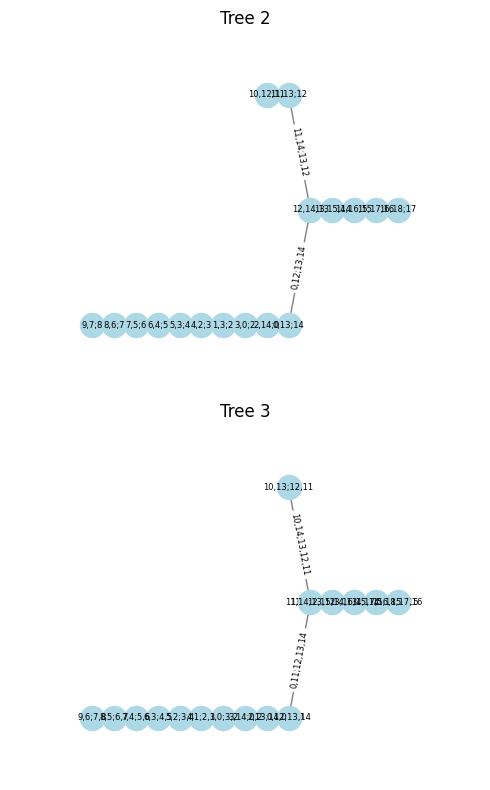

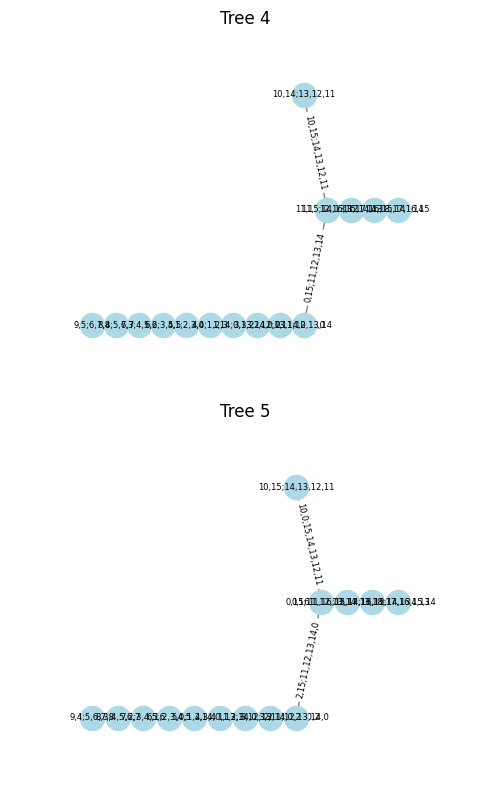

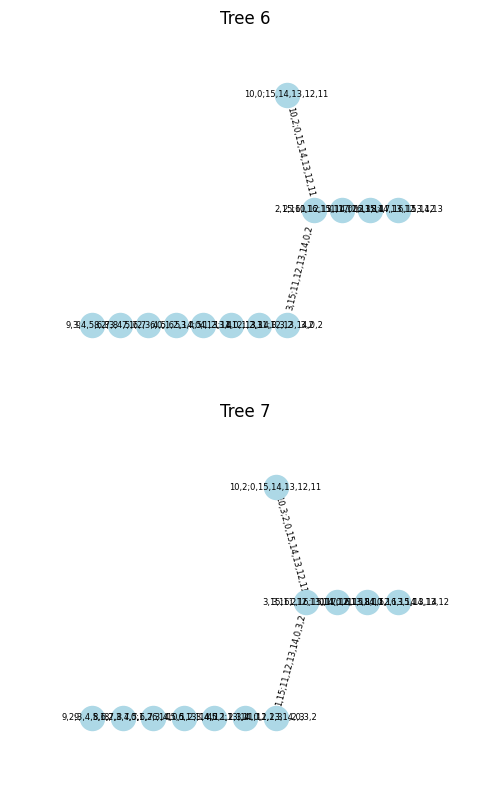

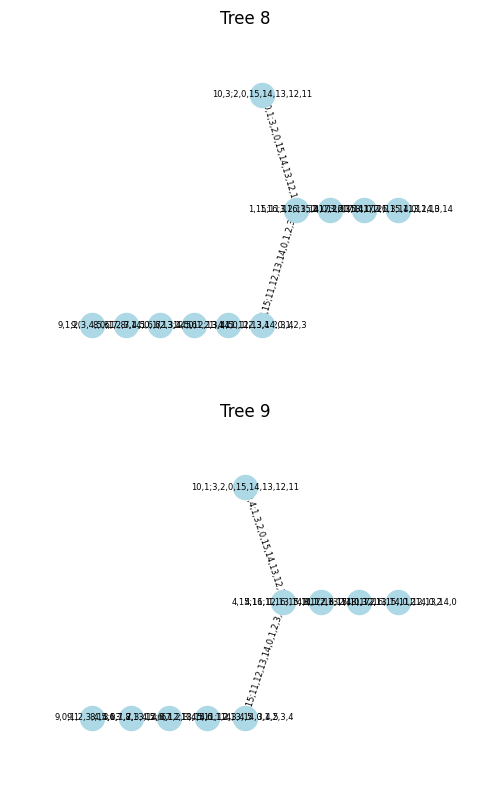

In [ ]:
cop.plot(tree=[0, 1])#, vars_names=var_names)
cop.plot(tree=[2, 3])#, vars_names=var_names)
cop.plot(tree=[4, 5])#, vars_names=var_names)
cop.plot(tree=[6, 7])#, vars_names=var_names)
cop.plot(tree=[8, 9])#, vars_names=var_names)

In [ ]:
from scipy.stats import gaussian_kde

def ecdf(train_z):
    n = len(train_z)
    sorted_z = np.sort(train_z)
    def cdf(z): return np.interp(z, sorted_z, np.arange(1, n+1) / n)
    return cdf

def make_pz_prior(train_z, bandwidth='scott'):
    """KDE over training redshifts — gives P(z) population prior."""
    kde = gaussian_kde(train_z, bw_method=bandwidth)
    def pz(z): return kde(z)
    return pz

def plot_pz(cop, phot_u, z_grid_raw, marginal_cdf_z, pz_prior=None,
            z_true=None, n_cols=4):
    """
    cop:            fitted Vinecop (10-dim, z is first column)
    phot_u:         shape (n_galaxies, 9) — photometry already in [0,1]
    z_grid_raw:     shape (K,) — redshift grid in original units
    marginal_cdf_z: callable — maps raw z to [0,1]
    pz_prior:       callable — P(z) population prior (optional). If None,
                    uses flat prior (original behaviour)
    z_true:         shape (n_galaxies,) — true redshifts, optional
    """
    z_grid_u = marginal_cdf_z(z_grid_raw)
    prior    = pz_prior(z_grid_raw) if pz_prior is not None else np.ones(len(z_grid_raw))

    n_gal  = phot_u.shape[0]
    n_rows = int(np.ceil(n_gal / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).flat

    for i, ax in enumerate(axes):
        if i >= n_gal:
            ax.set_visible(False)
            continue

        phot_tiled = np.tile(phot_u[i], (len(z_grid_u), 1))
        u_eval     = np.asfortranarray(
            np.hstack([z_grid_u.reshape(-1, 1),
                       phot_tiled])
        )

        log_pz     = np.log(cop.pdf(u_eval))
        log_prior  = np.log(prior + 1e-300)          # guard against log(0)
        log_post   = log_pz + log_prior               # log[ likelihood × P(z) ]

        ax.plot(z_grid_raw, np.exp(log_post - log_post.max()))

        if z_true is not None:
            ax.axvline(z_true[i], color='r', linestyle='--',
                       label=f"z_true = {z_true[i]:.3f}")
            ax.legend(fontsize=8)

        ax.set_xlabel("z")
        ax.set_ylabel("p(z|phot)·P(z)  [unnorm.]")
        ax.set_title(f"Galaxy {i}")

    plt.tight_layout()
    plt.show()

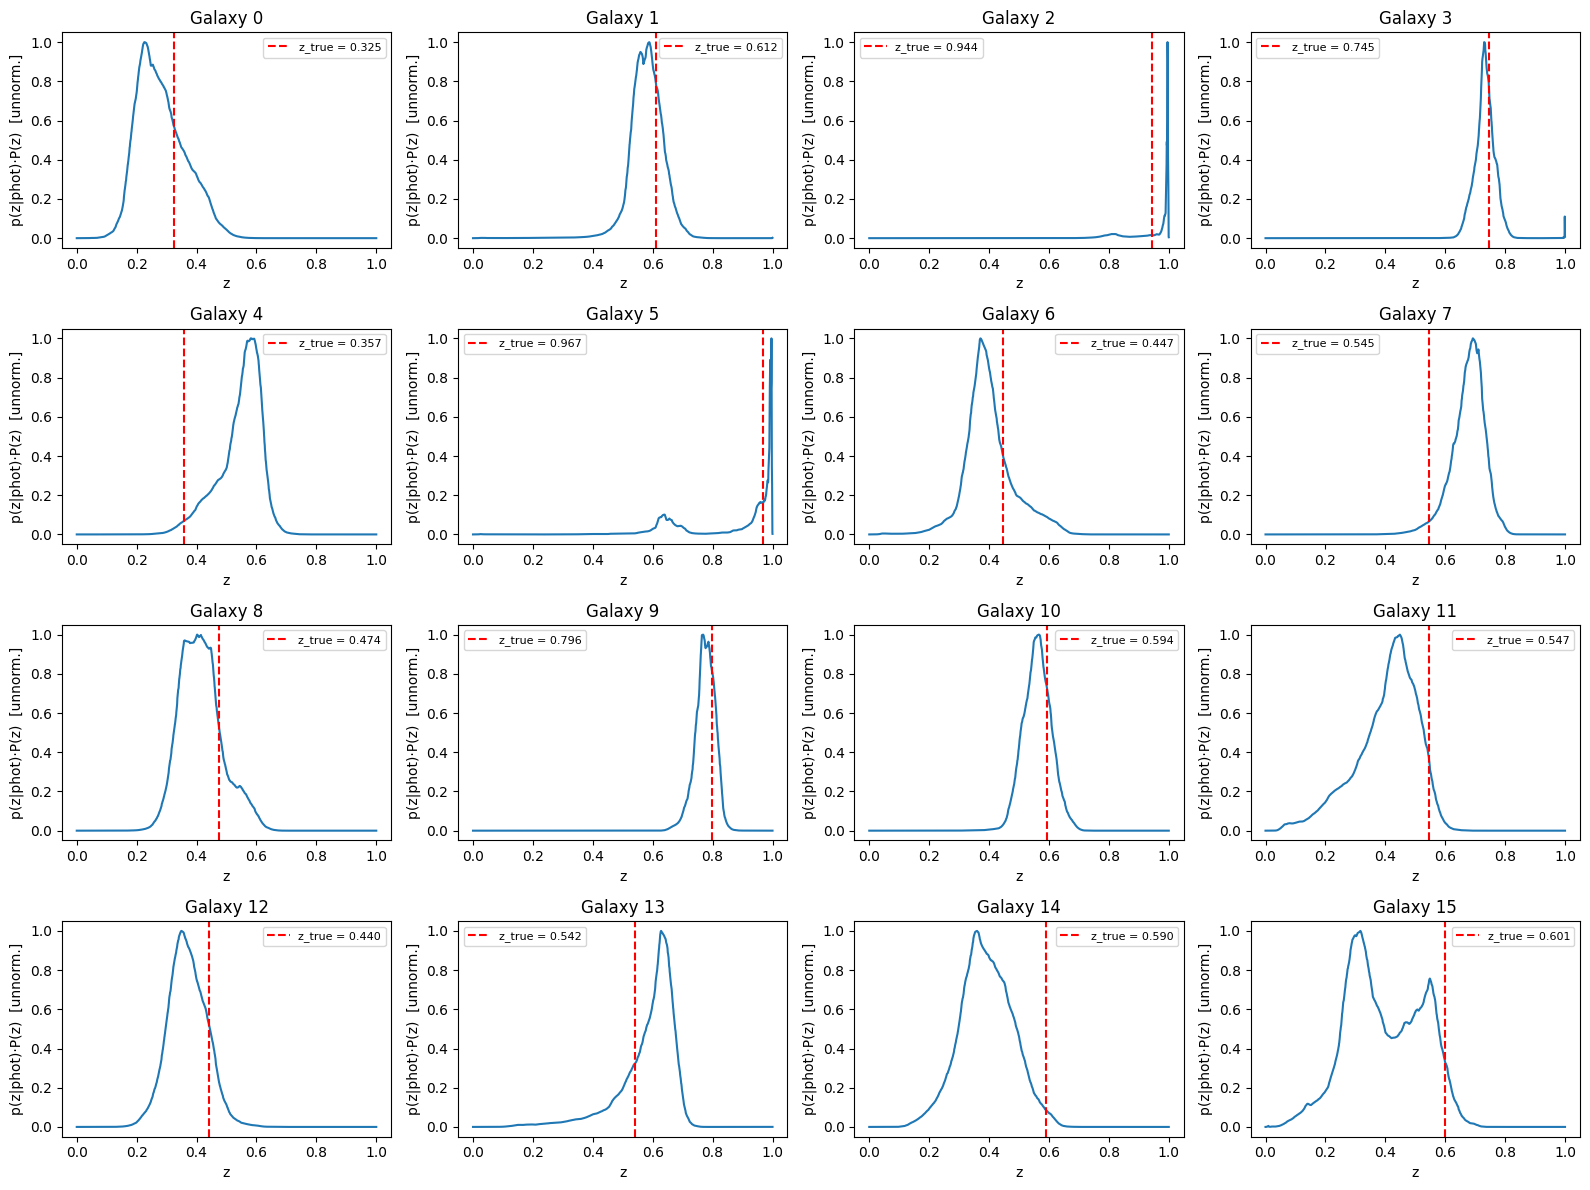

In [ ]:
pz_prior = make_pz_prior(u[:,0])   # build KDE from training data
z_grid = np.linspace(0, 1, 5000)

random_index = np.random.choice(u.shape[0], 16, replace=True)
phot_u_test = u[random_index, 1:] # select columns 1-18 for photometry
z_u_test    = u[random_index, 0] # select column 0 for redshift

marginal_cdf_z = ecdf(u[:,0])  # empirical CDF from training redshifts
plot_pz(
    cop            = cop,
    phot_u         = phot_u_test,
    z_grid_raw     = z_grid,
    marginal_cdf_z = marginal_cdf_z,
    pz_prior       = pz_prior,             # <-- new argument
    z_true         = z_u_test,
    n_cols         = 4,
)